# Data Redundancy Removal System











## Step 1: Install & Import Required Libraries

In [1]:

!pip install pandas faker tabulate --quiet

import pandas as pd
import hashlib
import json
import os
import re
from datetime import datetime
from faker import Faker
from tabulate import tabulate
from difflib import SequenceMatcher

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Initialize the Cloud Database (SQLite)

In [2]:
import sqlite3


DB_PATH = "cloud_database.db"

def get_connection():
    """Create and return a database connection."""
    return sqlite3.connect(DB_PATH)

def initialize_database():
    """Create tables if they don't exist."""
    conn = get_connection()
    cursor = conn.cursor()


    cursor.execute('''
        CREATE TABLE IF NOT EXISTS records (
            id          INTEGER PRIMARY KEY AUTOINCREMENT,
            name        TEXT NOT NULL,
            email       TEXT NOT NULL,
            phone       TEXT,
            data_hash   TEXT UNIQUE NOT NULL,
            inserted_at TEXT NOT NULL
        )
    ''')


    cursor.execute('''
        CREATE TABLE IF NOT EXISTS audit_log (
            id          INTEGER PRIMARY KEY AUTOINCREMENT,
            name        TEXT,
            email       TEXT,
            status      TEXT,
            reason      TEXT,
            attempted_at TEXT
        )
    ''')

    conn.commit()
    conn.close()
    print("Cloud database initialized successfully!")
    print(f"Database file: {DB_PATH}")

initialize_database()

Cloud database initialized successfully!
Database file: cloud_database.db


## Step 3: Core Hashing & Validation Engine

In [3]:

def generate_hash(record: dict) -> str:
    """
    Generate a SHA-256 hash from a record's canonical fields.
    Normalise values so 'John' and 'john ' hash identically.
    """
    canonical = json.dumps({
        "name":  record.get("name",  "").strip().lower(),
        "email": record.get("email", "").strip().lower(),
        "phone": re.sub(r"\D", "", record.get("phone", ""))
    }, sort_keys=True)
    return hashlib.sha256(canonical.encode()).hexdigest()



def is_valid_email(email: str) -> bool:
    pattern = r'^[\w\.-]+@[\w\.-]+\.\w{2,}$'
    return bool(re.match(pattern, email.strip()))

def is_valid_phone(phone: str) -> bool:
    digits = re.sub(r"\D", "", phone)
    return 7 <= len(digits) <= 15

def is_valid_name(name: str) -> bool:
    return bool(name and len(name.strip()) >= 2)

def validate_record(record: dict) -> tuple:
    """
    Returns (is_valid: bool, reason: str).
    Checks field formats before redundancy check.
    """
    if not is_valid_name(record.get("name", "")):
        return False, "Invalid name (too short or empty)"
    if not is_valid_email(record.get("email", "")):
        return False, f"Invalid email format: {record.get('email')}"
    if record.get("phone") and not is_valid_phone(record["phone"]):
        return False, f"Invalid phone number: {record.get('phone')}"
    return True, "Valid"



def is_duplicate_hash(data_hash: str) -> bool:
    """Exact duplicate via hash lookup — O(1)."""
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT 1 FROM records WHERE data_hash = ?", (data_hash,))
    result = cursor.fetchone()
    conn.close()
    return result is not None

def is_duplicate_email(email: str) -> bool:
    """Catch same email with different name/phone."""
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT 1 FROM records WHERE LOWER(email) = LOWER(?)", (email.strip(),))
    result = cursor.fetchone()
    conn.close()
    return result is not None

def fuzzy_name_match(name: str, threshold: float = 0.90) -> bool:
    """
    Check for near-duplicate names (typos, extra spaces).
    Returns True if a very similar name already exists.
    """
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM records")
    existing_names = [row[0] for row in cursor.fetchall()]
    conn.close()

    name_clean = name.strip().lower()
    for existing in existing_names:
        ratio = SequenceMatcher(None, name_clean, existing.strip().lower()).ratio()
        if ratio >= threshold:
            return True, existing
    return False, None


print("Hashing & validation engine ready!")

Hashing & validation engine ready!


## Step 4: Insert Engine with Full Redundancy Checks

In [4]:
def log_attempt(record: dict, status: str, reason: str):
    """Write every insertion attempt to the audit log."""
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute(
        "INSERT INTO audit_log (name, email, status, reason, attempted_at) VALUES (?,?,?,?,?)",
        (
            record.get("name", ""),
            record.get("email", ""),
            status,
            reason,
            datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        )
    )
    conn.commit()
    conn.close()


def insert_record(record: dict, verbose: bool = True) -> dict:
    """
    Main insertion function.
    Runs validation → hash check → email check → fuzzy name check.
    Only inserts when all checks pass.
    Returns a result dict with status and reason.
    """
    result = {"record": record, "status": None, "reason": None}


    valid, reason = validate_record(record)
    if not valid:
        result.update(status="INVALID", reason=reason)
        log_attempt(record, "INVALID", reason)
        if verbose: print(f"  INVALID    | {record['name']:<25} | {reason}")
        return result


    data_hash = generate_hash(record)
    if is_duplicate_hash(data_hash):
        reason = "Exact duplicate detected (hash match)"
        result.update(status="DUPLICATE", reason=reason)
        log_attempt(record, "DUPLICATE", reason)
        if verbose: print(f"  DUPLICATE  | {record['name']:<25} | {reason}")
        return result


    if is_duplicate_email(record["email"]):
        reason = f"Email already registered: {record['email']}"
        result.update(status="DUPLICATE", reason=reason)
        log_attempt(record, "DUPLICATE", reason)
        if verbose: print(f"  DUPLICATE  | {record['name']:<25} | {reason}")
        return result


    is_fuzzy, matched_name = fuzzy_name_match(record["name"])
    if is_fuzzy:
        reason = f"Near-duplicate name (matches '{matched_name}') — classified as False Positive"
        result.update(status="FALSE POS", reason=reason)
        log_attempt(record, "FALSE_POSITIVE", reason)
        if verbose: print(f"  FALSE POS | {record['name']:<25} | {reason}")
        return result


    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute(
        "INSERT INTO records (name, email, phone, data_hash, inserted_at) VALUES (?,?,?,?,?)",
        (
            record["name"].strip(),
            record["email"].strip().lower(),
            record.get("phone", "").strip(),
            data_hash,
            datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        )
    )
    conn.commit()
    conn.close()

    reason = "Unique record — inserted successfully"
    result.update(status="INSERTED", reason=reason)
    log_attempt(record, "INSERTED", reason)
    if verbose: print(f"  INSERTED   | {record['name']:<25} | {reason}")
    return result


print("Insert engine ready!")

Insert engine ready!


## Step 5: Run Demo — Batch Insertion with All Edge Cases

In [5]:

sample_data = [

    {"name": "Alice Johnson",   "email": "alice@example.com",  "phone": "+91-9876543210"},
    {"name": "Bob Smith",       "email": "bob@example.com",    "phone": "+91-9123456780"},
    {"name": "Carol White",     "email": "carol@example.com",  "phone": "+91-9988776655"},
    {"name": "David Brown",     "email": "david@example.com",  "phone": "+91-9001122334"},
    {"name": "Eva Green",       "email": "eva@example.com",    "phone": "+91-9012345678"},


    {"name": "Alice Johnson",   "email": "alice@example.com",  "phone": "+91-9876543210"},


    {"name": "Alice J.",        "email": "alice@example.com",  "phone": "+91-9000000001"},


    {"name": "Bob Smitth",      "email": "bobsmitth@example.com", "phone": "+91-9000000002"},


    {"name": "Frank Invalid",   "email": "not-an-email",       "phone": "+91-9000000003"},


    {"name": "Grace Error",     "email": "grace@example.com",  "phone": "123"},


    {"name": "",                "email": "noname@example.com", "phone": "+91-9000000005"},


    {"name": "Henry Ford",      "email": "henry@example.com",  "phone": "+91-9111222333"},
    {"name": "Irene Adler",     "email": "irene@example.com",  "phone": "+91-9444555666"},
]

print("="*70)
print("  STATUS        | RECORD NAME              | REASON")
print("="*70)

results = [insert_record(r) for r in sample_data]

print("="*70)
print(f"\nTotal attempted: {len(results)}")

  STATUS        | RECORD NAME              | REASON
  DUPLICATE  | Alice Johnson             | Exact duplicate detected (hash match)
  DUPLICATE  | Bob Smith                 | Exact duplicate detected (hash match)
  DUPLICATE  | Carol White               | Exact duplicate detected (hash match)
  DUPLICATE  | David Brown               | Exact duplicate detected (hash match)
  DUPLICATE  | Eva Green                 | Exact duplicate detected (hash match)
  DUPLICATE  | Alice Johnson             | Exact duplicate detected (hash match)
  DUPLICATE  | Alice J.                  | Email already registered: alice@example.com
  FALSE POS | Bob Smitth                | Near-duplicate name (matches 'Bob Smith') — classified as False Positive
  INVALID    | Frank Invalid             | Invalid email format: not-an-email
  INVALID    | Grace Error               | Invalid phone number: 123
  INVALID    |                           | Invalid name (too short or empty)
  DUPLICATE  | Henry Ford           

## Step 6: Summary Report

In [6]:
def print_summary():
    conn = get_connection()


    records_df = pd.read_sql_query(
        "SELECT id, name, email, phone, inserted_at FROM records ORDER BY id", conn
    )


    audit_df = pd.read_sql_query(
        "SELECT name, email, status, reason, attempted_at FROM audit_log ORDER BY id", conn
    )
    conn.close()


    status_counts = audit_df["status"].value_counts()

    print("\n" + "="*70)
    print("  FINAL DATABASE CONTENTS")
    print("="*70)
    print(tabulate(records_df, headers='keys', tablefmt='fancy_grid', showindex=False))

    print("\n" + "="*70)
    print("  FULL AUDIT LOG")
    print("="*70)
    print(tabulate(audit_df, headers='keys', tablefmt='fancy_grid', showindex=False))

    print("\n" + "="*70)
    print("  INSERTION STATISTICS")
    print("="*70)
    total = len(audit_df)
    inserted   = (audit_df["status"] == "INSERTED").sum()
    duplicates = (audit_df["status"] == "DUPLICATE").sum()
    invalid    = (audit_df["status"] == "INVALID").sum()
    false_pos  = (audit_df["status"] == "FALSE_POSITIVE").sum()

    print(f"  Total attempts      : {total}")
    print(f"  Inserted (unique) : {inserted}  ({inserted/total*100:.1f}%)")
    print(f"  Duplicates blocked: {duplicates}  ({duplicates/total*100:.1f}%)")
    print(f"  False positives  : {false_pos}  ({false_pos/total*100:.1f}%)")
    print(f"  Invalid records   : {invalid}  ({invalid/total*100:.1f}%)")
    print(f"  Database size     : {inserted} unique records")
    print("="*70)

print_summary()


  FINAL DATABASE CONTENTS
╒══════╤═══════════════╤═══════════════════╤════════════════╤═════════════════════╕
│   id │ name          │ email             │ phone          │ inserted_at         │
╞══════╪═══════════════╪═══════════════════╪════════════════╪═════════════════════╡
│    1 │ Alice Johnson │ alice@example.com │ +91-9876543210 │ 2026-05-23 17:02:22 │
├──────┼───────────────┼───────────────────┼────────────────┼─────────────────────┤
│    2 │ Bob Smith     │ bob@example.com   │ +91-9123456780 │ 2026-05-23 17:02:22 │
├──────┼───────────────┼───────────────────┼────────────────┼─────────────────────┤
│    3 │ Carol White   │ carol@example.com │ +91-9988776655 │ 2026-05-23 17:02:22 │
├──────┼───────────────┼───────────────────┼────────────────┼─────────────────────┤
│    4 │ David Brown   │ david@example.com │ +91-9001122334 │ 2026-05-23 17:02:22 │
├──────┼───────────────┼───────────────────┼────────────────┼─────────────────────┤
│    5 │ Eva Green     │ eva@example.com   │ +91-

## Step 7: Visualise Results with Charts

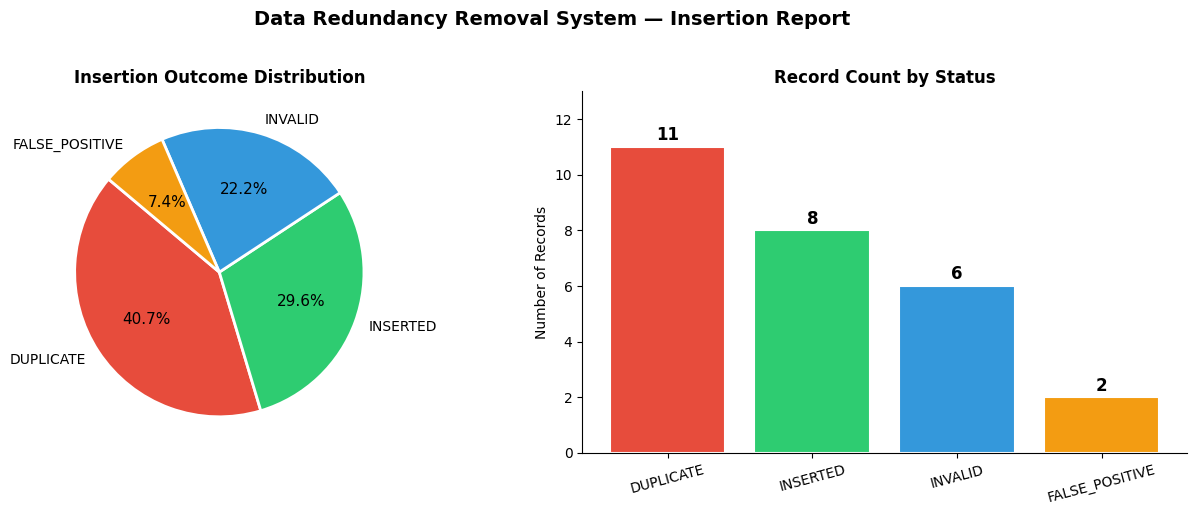

Chart saved as redundancy_report.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

conn = get_connection()
audit_df = pd.read_sql_query("SELECT status FROM audit_log", conn)
conn.close()

counts = audit_df["status"].value_counts()

labels   = counts.index.tolist()
sizes    = counts.values.tolist()
colors   = ["#2ecc71" if s=="INSERTED" else
            "#e74c3c" if s=="DUPLICATE" else
            "#f39c12" if s=="FALSE_POSITIVE" else
            "#3498db" for s in labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Data Redundancy Removal System — Insertion Report",
             fontsize=14, fontweight='bold', y=1.02)


wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(11)
axes[0].set_title("Insertion Outcome Distribution", fontweight='bold')


bars = axes[1].bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title("Record Count by Status", fontweight='bold')
axes[1].set_ylabel("Number of Records")
axes[1].set_ylim(0, max(sizes) + 2)
axes[1].tick_params(axis='x', rotation=15)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("redundancy_report.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as redundancy_report.png")

## Step 8: Interactive Query — Add Your Own Records

In [8]:

custom_records = [
    {"name": "Your Name",  "email": "your@email.com",  "phone": "+91-9000000000"},

]

print("Adding custom records...")
print("-"*70)
for rec in custom_records:
    insert_record(rec)

Adding custom records...
----------------------------------------------------------------------
  DUPLICATE  | Your Name                 | Exact duplicate detected (hash match)


## Step 9: Remove Duplicates from an Existing CSV (Bonus Feature)

In [9]:
from faker import Faker
import random

fake = Faker()


raw_rows = []
for _ in range(20):
    raw_rows.append({
        "name":  fake.name(),
        "email": fake.email(),
        "phone": fake.phone_number()[:13]
    })


duplicates = random.sample(raw_rows, 5)
raw_rows.extend(duplicates)
random.shuffle(raw_rows)

raw_df = pd.DataFrame(raw_rows)
raw_df.to_csv("raw_data.csv", index=False)
print(f"raw_data.csv created: {len(raw_df)} rows (includes duplicates)")


def deduplicate_csv(input_path: str, output_path: str):
    df = pd.read_csv(input_path)
    before = len(df)


    df["_hash"] = df.apply(
        lambda r: generate_hash({"name": str(r["name"]),
                                  "email": str(r["email"]),
                                  "phone": str(r["phone"])}), axis=1
    )


    df_clean = df.drop_duplicates(subset="_hash").drop(columns=["_hash"])
    after = len(df_clean)

    df_clean.to_csv(output_path, index=False)

    print(f"\n{'='*50}")
    print(f"  CSV De-duplication Report")
    print(f"{'='*50}")
    print(f"  Input rows   : {before}")
    print(f"  Output rows  : {after}")
    print(f"  Removed      : {before - after} duplicates")
    print(f"  Saved to     : {output_path}")
    print(f"{'='*50}")
    return df_clean

clean_df = deduplicate_csv("raw_data.csv", "clean_data.csv")
print("\nFirst 5 clean records:")
print(tabulate(clean_df.head(), headers='keys', tablefmt='fancy_grid', showindex=False))

raw_data.csv created: 25 rows (includes duplicates)

  CSV De-duplication Report
  Input rows   : 25
  Output rows  : 20
  Removed      : 5 duplicates
  Saved to     : clean_data.csv

First 5 clean records:
╒══════════════════╤════════════════════════════╤═══════════════╕
│ name             │ email                      │ phone         │
╞══════════════════╪════════════════════════════╪═══════════════╡
│ Lynn Best        │ abigailfox@example.com     │ (862)609-5645 │
├──────────────────┼────────────────────────────┼───────────────┤
│ Melvin Rodriguez │ turnerkaren@example.org    │ +1-632-912-61 │
├──────────────────┼────────────────────────────┼───────────────┤
│ Riley Rosario    │ uescobar@example.com       │ 996.714.8362x │
├──────────────────┼────────────────────────────┼───────────────┤
│ Robert Nichols   │ brice@example.com          │ (642)372-6854 │
├──────────────────┼────────────────────────────┼───────────────┤
│ Michele Ponce    │ martinezcassie@example.net │ 8933779492    │
╘

## Step 10: Final Summary

### What this system does:

| Feature | Implementation |
|---|---|
| **Exact duplicate detection** | SHA-256 hash of normalised fields |
| **Email uniqueness check** | Case-insensitive SQL lookup |
| **False positive classification** | Fuzzy name matching (SequenceMatcher) |
| **Field validation** | Regex-based email, phone, name checks |
| **Audit trail** | Full log of every insertion attempt |
| **CSV batch deduplication** | Hash-based pandas pipeline |
| **Visualisation** | Pie + bar chart of outcomes |
| **Cloud DB** | SQLite (swap for AWS RDS / GCP CloudSQL in production) |

---
